# Step 2: Flow-Based Estimation of $P(W \mid X, Z)$

This notebook implements **Section 3.2** of the paper: learning the conditional distribution of mediators $W$ given sensitive attribute $X$ and confounders $Z$, using the factorization:

$$P(W \mid X, Z) = P(W_\mathrm{disc} \mid X, Z) \cdot P(W_\mathrm{cont} \mid W_\mathrm{disc}, X, Z)$$

- **Discrete factor** $P(W_\mathrm{disc} \mid X, Z)$: parametrized by a neural network $g_\phi$ outputting categorical probabilities.
- **Continuous factor** $P(W_\mathrm{cont} \mid W_\mathrm{disc}, X, Z)$: modeled by a conditional normalizing flow $f_\theta$ (MAF / Neural Spline Flow).
- Both are **jointly optimized** via the combined log-likelihood.

The trained models are then used downstream for:
1. **NDE / NIE Monte Carlo estimation** (Step 3)
2. **Generating the counterfactual candidate pool** $\mathcal{C}(x, z)$ for recourse (Step 4)

## 0. Imports & Setup

In [1]:
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from nflows import transforms, distributions, flows
from nflows.transforms import (
    CompositeTransform,
    MaskedAffineAutoregressiveTransform,
    RandomPermutation,
)
from nflows.distributions import StandardNormal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import warnings
import os
from flow_diagnostics import plot_conditional_marginals, plot_ess_by_group

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. SFM Role Configuration

Specify which dataset columns play each SFM role. Edit this cell for your dataset.

| Role | Symbol | Description |
|------|--------|-------------|
| Sensitive | $X$ | Protected attribute (e.g. gender, race) |
| Confounders | $Z$ | Pre-treatment covariates not on causal path |
| Mediators (disc.) | $W_\mathrm{disc}$ | Actionable, discrete (e.g. education level) |
| Mediators (cont.) | $W_\mathrm{cont}$ | Actionable, continuous (e.g. GPA, hours worked) |
| Outcome | $Y$ | Decision label |

In [55]:
pd.read_csv("data/atherosclerosis.csv").head()

,Rank,ICO,ACTIV_JOB,ACTIV_AFT,TRANSP_JOB,TIME_JOB,BIRTH_YEAR,ENTRY_YEAR,AGE,ALCO_CONS,...,RSK_OBES,RSK_TOBA,RSK_HYPE,RSK_CHOL,GROUP,SUPER_GROU,DEATH_CAUS,DEATH_YEAR,DEATH_DELT,DEATH?
0,1,10215,1,2,3,6,26,77,51,1.16,...,1,1,1,0,3,R,7.0,92.0,15.0,1
1,2,10544,5,2,9,9,27,75,48,1.00,...,1,1,6,0,6,inconnu,5.0,76.0,1.0,1
2,3,10854,3,2,3,6,26,75,49,1.08,...,1,1,1,0,3,R,NaN,NaN,NaN,0
3,4,10786,3,3,3,5,27,75,48,1.26,...,1,1,0,0,3,R,6.0,94.0,19.0,1
4,5,10633,2,1,1,5,30,77,47,1.26,...,0,1,1,0,4,R,NaN,NaN,NaN,0


In [2]:
# ── Dataset ──────────────────────────────────────────────────────────────────
# Change DATASET_NAME to switch between datasets; the SFM_CONFIG dict maps
# each dataset to its SFM role assignment.

DATASET_NAME = "acs"   # or "acs", "arterosclerosis"

SFM_CONFIG = {
    "law_school": {
    "sensitive":      ["race"],
    "confounders":    ["gender", "fam_inc"],   # Z
    "mediators_disc": [],
    "mediators_cont": ["lsat", "gpa"],         # W_cont
    "outcome":        "bar_pass",
    },
    "acs": {
    "sensitive":      ["SEX"],
    "confounders":    ["AGEP", "POBP_US"],
    "mediators_disc": ["SCHL_GRP", "OCCP_GRP", "WKHP_GRP"],
    "mediators_cont": [],
    "outcome":        "income",
},
    "arterosclerosis": {
        "sensitive":       ["EDUCATION"],             # 1: university, 0: no university
        "confounders":     ["BIRTH_YEAR", "RSK_FAMI", "IM", "ICT", "TOBA_DURA", "DIAB"],
        "mediators_disc":  [],
        "mediators_cont":  ['SUBSC', 'TRIC', 'WEIGHT', 'TRIGL', 'SYST', 'DIAST', 'CHLST', 'ALCO_CONS', 'TOBA_CONS'],
        "outcome":         "DEATH",
    },
}

cfg = SFM_CONFIG[DATASET_NAME]
print("SFM assignment:")
for role, cols in cfg.items():
    print(f"  {role:20s}: {cols}")

SFM assignment:
  sensitive           : ['SEX']
  confounders         : ['AGEP', 'POBP_US']
  mediators_disc      : ['SCHL_GRP', 'COW', 'MAR', 'OCCP_GRP']
  mediators_cont      : ['WKHP']
  outcome             : income


## 2. Data Loading & Preprocessing

In [12]:
import data_acs, importlib
importlib.reload(data_acs)
from data_acs import load_acs_income

# Check the first few states in the default list
import inspect
src = inspect.getsource(load_acs_income)

In [13]:
def load_dataset(name: str) -> pd.DataFrame:
    """Load a dataset by name. Replace with your actual data paths."""
    if name == "law_school":
        df = pd.read_csv("data/bar.csv")
        cols = ['gender', 'race1', 'lsat', 'gpa', 'fam_inc', 'pass_bar']

        df = df[cols].dropna(subset=['gender', 'fam_inc']).copy()

        # Encode
        df['gender'] = df['gender'].map({'male': 1, 'female': 0})
        df['race']   = df['race1'].map({'white': 1, 'black': 0})
        df = df[df['race'].isin([0, 1])].drop(columns='race1')

        # Types
        df['fam_inc'] = df['fam_inc'].astype(int)
        df['lsat']    = df['lsat'].round(0).astype(int)
        df = df.rename(columns={'pass_bar': 'bar_pass'})
        return df

    elif name == "acs":
        from data_acs import load_acs_income
        return load_acs_income(year=2018)

    elif name == "pima":
        url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
        cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
                "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
        df = pd.read_csv(url, names=cols)
        df["Age"] = (df["Age"] >= 35).astype(int)
        return df

    raise ValueError(f"Unknown dataset: {name}")

In [14]:
df_raw = load_dataset(DATASET_NAME)
print(f"Loaded {len(df_raw):,} rows  |  columns: {list(df_raw.columns)}")
df_raw.head()

folktables received states: ['CA']
Raw rows: 195,665
Final rows : 195,665
Income >$50k: 0.000
Female share: 0.472
Male share  : 0.528
Loaded 195,665 rows  |  columns: ['SEX', 'AGEP', 'POBP_US', 'SCHL_GRP', 'COW', 'MAR', 'OCCP_GRP', 'WKHP', 'income']


,SEX,AGEP,POBP_US,SCHL_GRP,COW,MAR,OCCP_GRP,WKHP,income
0,1,30.0,1,0,5,0,9,40.0,0
1,1,21.0,1,1,3,4,5,20.0,0
2,1,65.0,1,4,1,4,6,8.0,0
3,1,33.0,1,0,0,2,9,40.0,0
4,0,18.0,1,2,1,4,3,18.0,0


In [15]:
def build_tensors(df: pd.DataFrame, cfg: dict, scaler=None, fit_scaler=True):
    """
    Project a DataFrame onto the SFM roles and return:
      X_t      : sensitive attribute(s)          shape (N, |X|)
      Z_t      : confounders                     shape (N, |Z|)
      W_disc_t : discrete mediators (long)       shape (N, |W_disc|)
      W_cont_t : continuous mediators (float32)  shape (N, |W_cont|)
      Y_t      : outcome                         shape (N,)
      scaler   : fitted StandardScaler on W_cont
      vocab    : dict mapping each W_disc column -> number of categories
    """
    X_cols      = cfg["sensitive"]
    Z_cols      = cfg["confounders"]
    Wd_cols     = cfg["mediators_disc"]
    Wc_cols     = cfg["mediators_cont"]
    y_col       = cfg["outcome"]

    # One-hot encode discrete mediators if they are strings / categoricals
    vocab = {}
    Wd_arrays = []
    for col in Wd_cols:
        if df[col].dtype == object or str(df[col].dtype) == "category" or pd.api.types.is_string_dtype(df[col]):
            cats = sorted(df[col].unique())
            mapping = {c: i for i, c in enumerate(cats)}
            Wd_arrays.append(df[col].map(mapping).values)
            vocab[col] = len(cats)
        else:
            Wd_arrays.append(df[col].values.astype(int))
            vocab[col] = int(df[col].max()) + 1

    # Standardize continuous mediators
    Wc_np = df[Wc_cols].values.astype(np.float32) if Wc_cols else np.empty((len(df), 0), dtype=np.float32)
    if fit_scaler and Wc_cols:
        scaler = StandardScaler()
        Wc_np  = scaler.fit_transform(Wc_np).astype(np.float32)
    elif scaler is not None and Wc_cols:
        Wc_np  = scaler.transform(Wc_np).astype(np.float32)

    X_np  = df[X_cols].values.astype(np.float32)  if X_cols else np.empty((len(df), 0), np.float32)
    
    # encode the confounders as floats; if they are strings/categoricals, map to integers first
    if Z_cols:
        Z_parts = []
        for col in Z_cols:
            if pd.api.types.is_string_dtype(df[col]) or str(df[col].dtype) == "category":
                cats    = sorted(df[col].unique())
                mapping = {c: i for i, c in enumerate(cats)}
                Z_parts.append(df[col].map(mapping).values.astype(np.float32))
            else:
                Z_parts.append(df[col].values.astype(np.float32))
        Z_np = np.column_stack(Z_parts)
    else:
        Z_np = np.empty((len(df), 0), np.float32)



    Y_np  = df[y_col].values.astype(np.float32)

    to_t  = lambda a: torch.tensor(a, dtype=torch.float32)
    X_t   = to_t(X_np)
    Z_t   = to_t(Z_np)
    W_disc_t = torch.tensor(np.column_stack(Wd_arrays), dtype=torch.long) if Wd_arrays else torch.empty(len(df), 0, dtype=torch.long)
    W_cont_t = to_t(Wc_np)
    Y_t   = to_t(Y_np)

    return X_t, Z_t, W_disc_t, W_cont_t, Y_t, scaler, vocab


# Train / val split
idx_tr, idx_val = train_test_split(np.arange(len(df_raw)), test_size=0.2, random_state=42)
df_tr  = df_raw.iloc[idx_tr].reset_index(drop=True)
df_val = df_raw.iloc[idx_val].reset_index(drop=True)

X_tr, Z_tr, Wd_tr, Wc_tr, Y_tr, scaler, vocab = build_tensors(df_tr,  cfg, fit_scaler=True)
X_va, Z_va, Wd_va, Wc_va, Y_va, _,      _     = build_tensors(df_val, cfg, scaler=scaler, fit_scaler=False)

dim_x   = X_tr.shape[1]
dim_z   = Z_tr.shape[1]
dim_wc  = Wc_tr.shape[1]
dim_wd  = Wd_tr.shape[1]

print(f"Train: {len(df_tr):,}  Val: {len(df_val):,}")
print(f"dim_x={dim_x}  dim_z={dim_z}  dim_W_disc={dim_wd}  dim_W_cont={dim_wc}")
print(f"Discrete mediator vocab: {vocab}")

Train: 156,532  Val: 39,133
dim_x=1  dim_z=2  dim_W_disc=4  dim_W_cont=1
Discrete mediator vocab: {'SCHL_GRP': 6, 'COW': 8, 'MAR': 5, 'OCCP_GRP': 10}


## 3. Model Architecture

### 3a. Discrete Factor $g_\phi$: $P(W_\mathrm{disc} \mid X, Z)$

A shared MLP backbone that produces per-column logits for each discrete mediator.

In [16]:
class DiscreteMediator(nn.Module):
    """
    Models P(W_disc | X, Z) as a product of independent categoricals,
    conditioned on [X; Z] via a shared MLP backbone.

    If vocab is empty (no discrete mediators), log_prob returns 0 and
    sample returns an empty tensor.
    """

    def __init__(self, dim_x: int, dim_z: int, vocab: dict,
                 hidden_dim: int = 64, n_layers: int = 2):
        super().__init__()
        self.vocab     = vocab           # {col_name: n_categories}
        self.col_names = list(vocab.keys())
        n_cats         = list(vocab.values())

        in_dim = dim_x + dim_z
        if in_dim == 0 or not vocab:
            self.backbone = None
            self.heads    = None
            return

        layers = []
        d = in_dim
        for _ in range(n_layers):
            layers += [nn.Linear(d, hidden_dim), nn.ReLU()]
            d = hidden_dim
        self.backbone = nn.Sequential(*layers)
        # One output head per discrete mediator column
        self.heads = nn.ModuleList([
            nn.Linear(hidden_dim, k) for k in n_cats
        ])

    def _cond(self, x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        parts = [p for p in [x, z] if p.shape[1] > 0]
        return torch.cat(parts, dim=1) if parts else None

    def log_prob(self, w_disc: torch.Tensor,
                 x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        """Returns (N,) log-prob summed over discrete mediator columns."""
        if not self.vocab:
            return torch.zeros(x.shape[0], device=x.device)

        h     = self.backbone(self._cond(x, z))
        total = torch.zeros(x.shape[0], device=x.device)
        for i, head in enumerate(self.heads):
            logits = head(h)
            total += F.cross_entropy(logits, w_disc[:, i], reduction="none") * -1.0
        return total  # sum of log-probs across columns

    @torch.no_grad()
    def sample(self, x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        """Returns (N, |W_disc|) sampled discrete mediator indices."""
        if not self.vocab:
            return torch.empty(x.shape[0], 0, dtype=torch.long, device=x.device)

        h = self.backbone(self._cond(x, z))
        cols = []
        for head in self.heads:
            probs = torch.softmax(head(h), dim=-1)
            cols.append(torch.multinomial(probs, 1))
        return torch.cat(cols, dim=1)  # (N, |W_disc|)


g_phi = DiscreteMediator(dim_x, dim_z, vocab, hidden_dim=64).to(DEVICE)
print(g_phi)

DiscreteMediator(
  (backbone): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (heads): ModuleList(
    (0): Linear(in_features=64, out_features=6, bias=True)
    (1): Linear(in_features=64, out_features=8, bias=True)
    (2): Linear(in_features=64, out_features=5, bias=True)
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


### 3b. Continuous Factor $f_\theta$: $P(W_\mathrm{cont} \mid W_\mathrm{disc}, X, Z)$

A **conditional Masked Autoregressive Flow (MAF)** from `nflows`. 
The conditioning context is $h = [X; W_\mathrm{disc}^{\text{emb}}; Z]$, where discrete
mediators are passed through learned embeddings before concatenation.

In [17]:
class ContinuousMediatorFlow(nn.Module):
    """
    Models P(W_cont | W_disc, X, Z) via a conditional normalizing flow.

    Architecture:
      - Embedding layer for each discrete mediator column.
      - Conditioning context = [embed(W_disc); X; Z]
      - n_flow_layers of MaskedAffineAutoregressiveTransform with
        RandomPermutation between layers.
      - Standard normal base distribution.
    """

    def __init__(self,
                 dim_wc: int,
                 dim_x: int,
                 dim_z: int,
                 vocab: dict,
                 embed_dim: int = 4,
                 hidden_features: int = 64,
                 n_flow_layers: int = 4,
                 n_blocks: int = 2):
        super().__init__()
        self.dim_wc = dim_wc

        # Learned embeddings for discrete mediators
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cats, embed_dim)
            for n_cats in vocab.values()
        ])
        dim_embed = len(vocab) * embed_dim
        self.dim_context = dim_embed + dim_x + dim_z

        if dim_wc == 0:
            self.flow = None
            return

        # Stack of conditional MAF transforms
        transform_list = []
        for _ in range(n_flow_layers):
            transform_list.append(
                MaskedAffineAutoregressiveTransform(
                    features=dim_wc,
                    hidden_features=hidden_features,
                    context_features=self.dim_context if self.dim_context > 0 else None,
                    num_blocks=n_blocks,
                    use_residual_blocks=True,
                    activation=F.relu,
                )
            )
            if dim_wc > 1:
                transform_list.append(RandomPermutation(features=dim_wc))

        self.flow = flows.Flow(
            transform=CompositeTransform(transform_list),
            distribution=StandardNormal(shape=[dim_wc]),
        )

    def _build_context(self, w_disc: torch.Tensor,
                        x: torch.Tensor, z: torch.Tensor) -> torch.Tensor | None:
        parts = []
        for i, emb in enumerate(self.embeddings):
            parts.append(emb(w_disc[:, i]))
        parts += [p for p in [x, z] if p.shape[1] > 0]
        if not parts:
            return None
        return torch.cat(parts, dim=1)  # (N, dim_context)

    def log_prob(self, w_cont: torch.Tensor,
                 w_disc: torch.Tensor,
                 x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        """Returns (N,) log-prob of continuous mediators."""
        if self.dim_wc == 0 or self.flow is None:
            return torch.zeros(x.shape[0], device=x.device)
        context = self._build_context(w_disc, x, z)
        return self.flow.log_prob(w_cont, context=context)

    @torch.no_grad()
    def sample(self, n: int, w_disc: torch.Tensor,
            x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        """Returns (N, dim_wc) samples from the conditional flow."""
        if self.dim_wc == 0 or self.flow is None:
            return torch.empty(x.shape[0], 0, device=x.device)
        context = self._build_context(w_disc, x, z)
        # flow.sample(1, context) returns (N, 1, dim_wc) — one sample per context row
        return self.flow.sample(1, context=context).squeeze(1)  # (N, dim_wc)

    @torch.no_grad()
    def log_prob_no_grad(self, w_cont, w_disc, x, z):
        """Convenience wrapper for inference-time log_prob."""
        if self.dim_wc == 0 or self.flow is None:
            return torch.zeros(x.shape[0], device=x.device)
        context = self._build_context(w_disc, x, z)
        return self.flow.log_prob(w_cont, context=context)


f_theta = ContinuousMediatorFlow(
    dim_wc=dim_wc,
    dim_x=dim_x,
    dim_z=dim_z,
    vocab=vocab,
    embed_dim=4,
    hidden_features=64,
    n_flow_layers=4,
).to(DEVICE)
print(f_theta)
print(f"\nContext dimension: {f_theta.dim_context}")

ContinuousMediatorFlow(
  (embeddings): ModuleList(
    (0): Embedding(6, 4)
    (1): Embedding(8, 4)
    (2): Embedding(5, 4)
    (3): Embedding(10, 4)
  )
  (flow): Flow(
    (_transform): CompositeTransform(
      (_transforms): ModuleList(
        (0-3): 4 x MaskedAffineAutoregressiveTransform(
          (autoregressive_net): MADE(
            (initial_layer): MaskedLinear(in_features=1, out_features=64, bias=True)
            (context_layer): Linear(in_features=19, out_features=64, bias=True)
            (blocks): ModuleList(
              (0-1): 2 x MaskedResidualBlock(
                (context_layer): Linear(in_features=19, out_features=64, bias=True)
                (linear_layers): ModuleList(
                  (0-1): 2 x MaskedLinear(in_features=64, out_features=64, bias=True)
                )
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
            (final_layer): MaskedLinear(in_features=64, out_features=2, bias=True)
          )
  

## 4. Joint Training

Maximize the combined log-likelihood from Eq. (3.2) in the paper:

$$\max_{\theta, \phi} \; \frac{1}{n} \sum_{i=1}^{n}
  \Bigl[\log p_\phi(w_{\mathrm{disc},i} \mid x_i, z_i)
        + \log p_\theta(w_{\mathrm{cont},i} \mid w_{\mathrm{disc},i}, x_i, z_i)\Bigr]$$

In [18]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE = 256
MAX_EPOCHS = 100
LR         = 1e-3
PATIENCE   = 10       # early stopping patience (epochs)
# ─────────────────────────────────────────────────────────────────────────────


def make_loader(X, Z, Wd, Wc, Y, batch_size, shuffle=True):
    ds = TensorDataset(X, Z, Wd, Wc, Y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

tr_loader  = make_loader(X_tr, Z_tr, Wd_tr, Wc_tr, Y_tr, BATCH_SIZE)
val_loader = make_loader(X_va, Z_va, Wd_va, Wc_va, Y_va, BATCH_SIZE, shuffle=False)


def combined_loss(batch, g_phi, f_theta):
    """Negative joint log-likelihood (to minimize)."""
    x, z, w_disc, w_cont = [t.to(DEVICE) for t in batch[:4]]

    ll_disc = g_phi.log_prob(w_disc, x, z)            # (N,)
    ll_cont = f_theta.log_prob(w_cont, w_disc, x, z)  # (N,)
    return -(ll_disc + ll_cont).mean()


@torch.no_grad()
def evaluate(loader, g_phi, f_theta):
    total, n = 0.0, 0
    for batch in loader:
        loss = combined_loss(batch, g_phi, f_theta)
        bs   = batch[0].shape[0]
        total += loss.item() * bs
        n    += bs
    return total / n


# ── Optimiser & scheduler ─────────────────────────────────────────────────────
params    = list(g_phi.parameters()) + list(f_theta.parameters())
optimiser = Adam(params, lr=LR)
scheduler = ReduceLROnPlateau(optimiser, patience=5, factor=0.5)

history    = {"train": [], "val": []}
best_val   = float("inf")
best_state = None
wait       = 0

print(f"{'Epoch':>5}  {'Train NLL':>12}  {'Val NLL':>12}  {'LR':>10}")
print("-" * 48)

for epoch in range(1, MAX_EPOCHS + 1):
    # ── train ──
    g_phi.train(); f_theta.train()
    tr_loss_sum, tr_n = 0.0, 0
    for batch in tr_loader:
        optimiser.zero_grad()
        loss = combined_loss(batch, g_phi, f_theta)
        loss.backward()
        nn.utils.clip_grad_norm_(params, 1.0)
        optimiser.step()
        bs           = batch[0].shape[0]
        tr_loss_sum += loss.item() * bs
        tr_n        += bs

    tr_nll  = tr_loss_sum / tr_n

    # ── validate ──
    g_phi.eval(); f_theta.eval()
    val_nll = evaluate(val_loader, g_phi, f_theta)
    scheduler.step(val_nll)

    history["train"].append(tr_nll)
    history["val"].append(val_nll)

    lr_now = optimiser.param_groups[0]["lr"]
    print(f"{epoch:5d}  {tr_nll:12.4f}  {val_nll:12.4f}  {lr_now:10.2e}")

    # ── early stopping ──
    if val_nll < best_val:
        best_val   = val_nll
        best_state = {
            "g_phi":   {k: v.cpu().clone() for k, v in g_phi.state_dict().items()},
            "f_theta": {k: v.cpu().clone() for k, v in f_theta.state_dict().items()},
            "epoch":   epoch,
        }
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val NLL: {best_val:.4f}")
            break

# Restore best weights
g_phi.load_state_dict(best_state["g_phi"])
f_theta.load_state_dict(best_state["f_theta"])
g_phi.to(DEVICE); f_theta.to(DEVICE)
print(f"\nBest model from epoch {best_state['epoch']}, val NLL = {best_val:.4f}")

Epoch     Train NLL       Val NLL          LR
------------------------------------------------
    1        7.3490        7.0457    1.00e-03
    2        6.8841        6.8088    1.00e-03
    3        6.8064        6.7640    1.00e-03
    4        6.7862        6.7384    1.00e-03
    5        6.7656        6.7200    1.00e-03
    6        6.7309        6.7304    1.00e-03
    7        6.7122        6.6907    1.00e-03
    8        6.7017        6.6782    1.00e-03
    9        6.6958        6.7041    1.00e-03
   10        6.6972        6.6757    1.00e-03
   11        6.6923        6.6621    1.00e-03
   12        6.6875        6.6665    1.00e-03
   13        6.6830        6.6668    1.00e-03
   14        6.6818        6.6777    1.00e-03
   15        6.6784        6.6750    1.00e-03
   16        6.6762        6.6589    1.00e-03
   17        6.6754        6.6926    1.00e-03
   18        6.6712        6.6669    1.00e-03
   19        6.6680        6.6503    1.00e-03
   20        6.6641        6.66

KeyboardInterrupt: 

## 5. Training Diagnostics

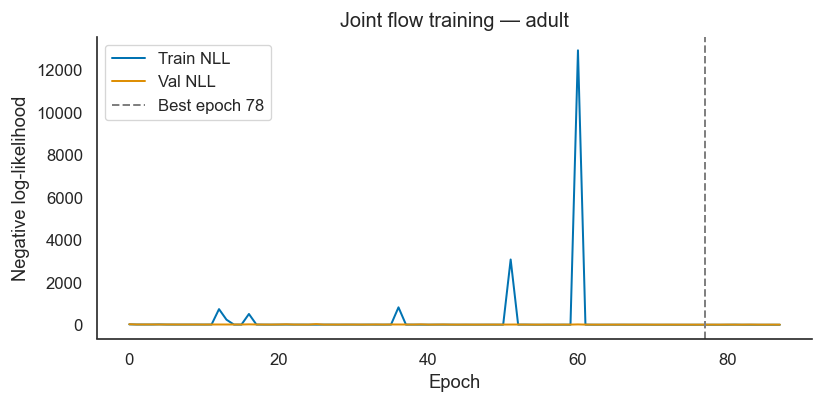

In [47]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(history["train"], label="Train NLL")
ax.plot(history["val"],   label="Val NLL")
ax.axvline(best_state["epoch"] - 1, color="grey", ls="--", label=f"Best epoch {best_state['epoch']}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative log-likelihood")
ax.set_title(f"Joint flow training — {DATASET_NAME}")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sampling Utilities

These functions are the primary interface for downstream steps (NDE/NIE computation and recourse candidate pool generation).

In [48]:
@torch.no_grad()
def sample_w_given_xz(x: torch.Tensor, z: torch.Tensor,
                       K: int = 500) -> dict:
    """
    Ancestral sampling from P(W | X=x, Z=z) for a batch of individuals.

    Parameters
    ----------
    x : (N, dim_x) sensitive attributes
    z : (N, dim_z) confounders
    K : number of samples per individual

    Returns
    -------
    dict with keys:
      "w_disc"  : (N*K, dim_wd) long tensor  (discrete mediators)
      "w_cont"  : (N*K, dim_wc) float tensor (continuous mediators, standardized)
      "w_cont_orig" : (N*K, dim_wc) float tensor (continuous mediators, original scale)
      "log_prob": (N*K,) total log-prob under P(W|x,z)
      "x_rep"   : (N*K, dim_x) x repeated K times
      "z_rep"   : (N*K, dim_z) z repeated K times
    """
    g_phi.eval(); f_theta.eval()
    x, z = x.to(DEVICE), z.to(DEVICE)
    N    = x.shape[0]

    # Repeat each individual K times for batch sampling
    x_rep = x.repeat_interleave(K, dim=0)  # (N*K, dim_x)
    z_rep = z.repeat_interleave(K, dim=0)  # (N*K, dim_z)

    # Step 1: sample discrete mediators
    w_disc_s = g_phi.sample(x_rep, z_rep)  # (N*K, dim_wd)

    # Step 2: sample continuous mediators conditioned on discrete
    w_cont_s = f_theta.sample(1, w_disc_s, x_rep, z_rep)  # (1, dim_wc)

    # Log-prob of each sample
    ll_disc = g_phi.log_prob(w_disc_s, x_rep, z_rep)
    ll_cont = f_theta.log_prob_no_grad(w_cont_s, w_disc_s, x_rep, z_rep)
    log_prob = ll_disc + ll_cont

    # Invert standardization for interpretable output
    if scaler is not None and dim_wc > 0:
        w_cont_orig = torch.tensor(
            scaler.inverse_transform(w_cont_s.cpu().numpy()),
            dtype=torch.float32
        )
    else:
        w_cont_orig = w_cont_s.cpu()

    return {
        "w_disc":      w_disc_s.cpu(),
        "w_cont":      w_cont_s.cpu(),
        "w_cont_orig": w_cont_orig,
        "log_prob":    log_prob.cpu(),
        "x_rep":       x_rep.cpu(),
        "z_rep":       z_rep.cpu(),
    }


@torch.no_grad()
def log_prob_w_given_xz(w_disc: torch.Tensor, w_cont: torch.Tensor,
                         x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    """
    Evaluate log P(W=w | X=x, Z=z) for given (w, x, z) triples.
    Used for IS weight computation in the NIE estimator.

    Parameters
    ----------
    w_disc  : (N, dim_wd)
    w_cont  : (N, dim_wc)  — standardized scale
    x       : (N, dim_x)
    z       : (N, dim_z)

    Returns
    -------
    log_prob : (N,)
    """
    g_phi.eval(); f_theta.eval()
    w_disc, w_cont, x, z = [t.to(DEVICE) for t in [w_disc, w_cont, x, z]]
    ll_disc = g_phi.log_prob(w_disc, x, z)
    ll_cont = f_theta.log_prob_no_grad(w_cont, w_disc, x, z)
    return (ll_disc + ll_cont).cpu()


print("Sampling utilities defined.")

Sampling utilities defined.


## 7. Sanity Checks

In [49]:
# ── 7a. Sample from the flow and compare marginals ───────────────────────────
N_check = 5
x_check = X_va[:N_check]
z_check = Z_va[:N_check]

out = sample_w_given_xz(x_check, z_check, K=50)  # 50 is enough to check shapes
print("Sample output shapes:")
for k, v in out.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

Sample output shapes:
  w_disc         : (250, 4)
  w_cont         : (250, 3)
  w_cont_orig    : (250, 3)
  log_prob       : (250,)
  x_rep          : (250, 1)
  z_rep          : (250, 2)


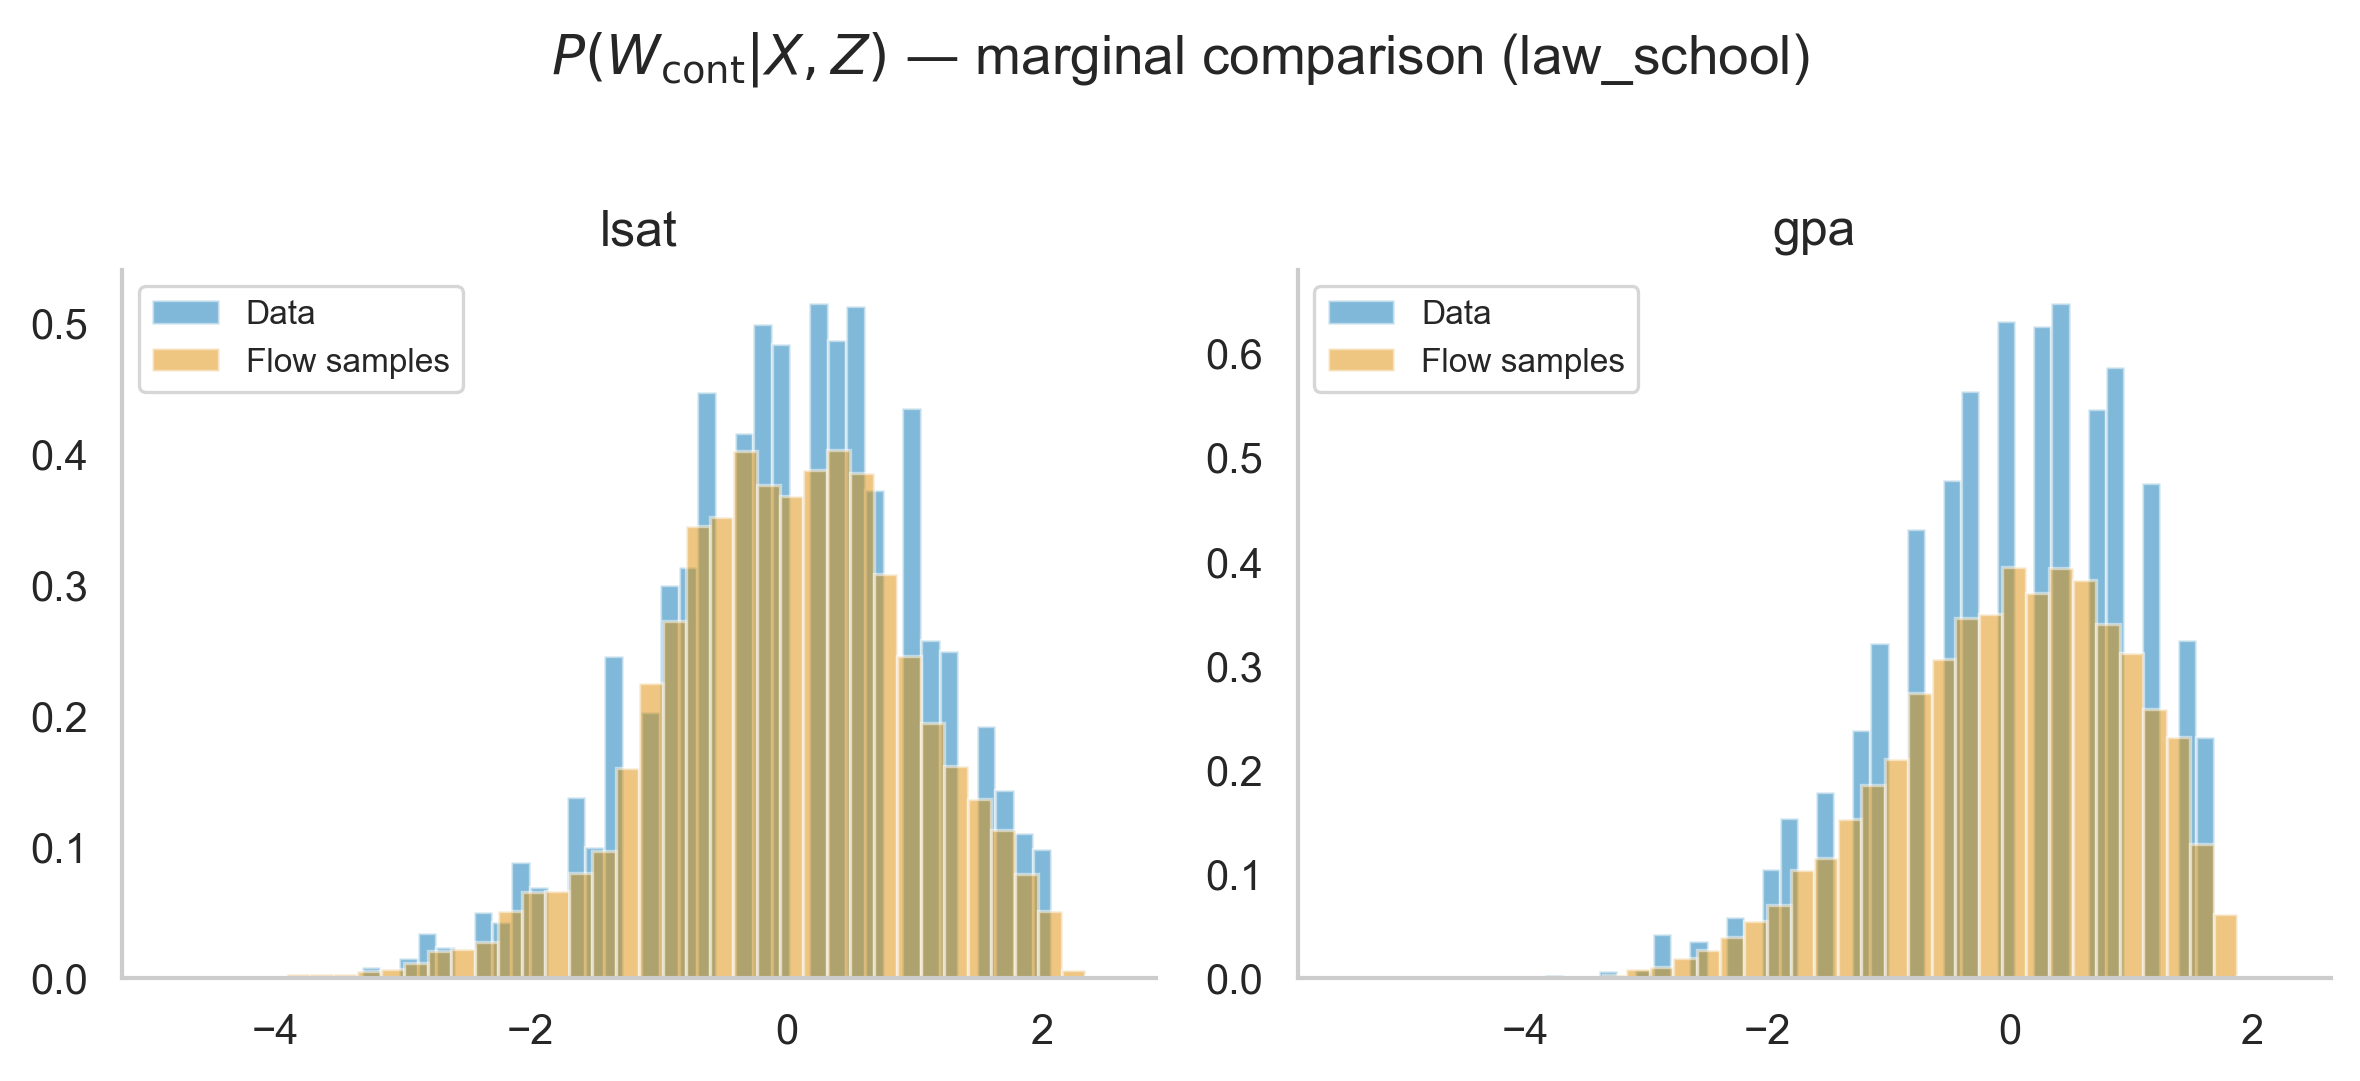

In [10]:
if dim_wc > 0:
    # Compare empirical marginals in val set vs samples from flow
    wc_names = cfg["mediators_cont"]
    n_cols   = min(dim_wc, 4)

    # Draw samples conditioning on all val individuals
    out_full = sample_w_given_xz(X_va, Z_va, K=5)
    w_cont_sampled = out_full["w_cont"].numpy()  # (N_val*5, dim_wc)
    w_cont_true    = Wc_va.numpy()

    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3.5))
    if n_cols == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.hist(w_cont_true[:, i],    bins=40, alpha=0.5, density=True, label="Data")
        ax.hist(w_cont_sampled[:, i], bins=40, alpha=0.5, density=True, label="Flow samples")
        ax.set_title(wc_names[i])
        ax.legend(fontsize=8)
    fig.suptitle(f"$P(W_{{\\mathrm{{cont}}}}|X,Z)$ — marginal comparison ({DATASET_NAME})", y=1.02)
    plt.tight_layout()
    plt.show()

In [57]:
from flow_diagnostics_shared import plot_conditional_marginals, plot_ess_by_group, GROUP_LABEL_PRESETS

# Law school
plot_conditional_marginals(..., group_labels=GROUP_LABEL_PRESETS["law_school"])

# Adult
plot_conditional_marginals(..., group_labels=GROUP_LABEL_PRESETS["adult"])
plot_ess_by_group(..., group_labels=GROUP_LABEL_PRESETS["adult"])

# PIMA
plot_ess_by_group(..., group_labels=GROUP_LABEL_PRESETS["pima"])

# Or pass a custom dict directly for any other encoding:
plot_ess_by_group(..., group_labels={0: "Low income", 1: "High income"})

ImportError: cannot import name 'GROUP_LABEL_PRESETS' from 'flow_diagnostics_shared' (c:\Users\andre\Documents\counterfactual-recourse\flow_diagnostics_shared.py)

In [5]:
import importlib
import data_acs


importlib.reload(data_acs)

<module 'data_acs' from 'c:\\Users\\andre\\Documents\\counterfactual-recourse\\data_acs.py'>

In [50]:
import importlib
import flow_diagnostics_shared

importlib.reload(flow_diagnostics_shared)

from flow_diagnostics_shared import (
    plot_conditional_marginals,
    plot_ess_by_group,
    plot_k_sensitivity,
)

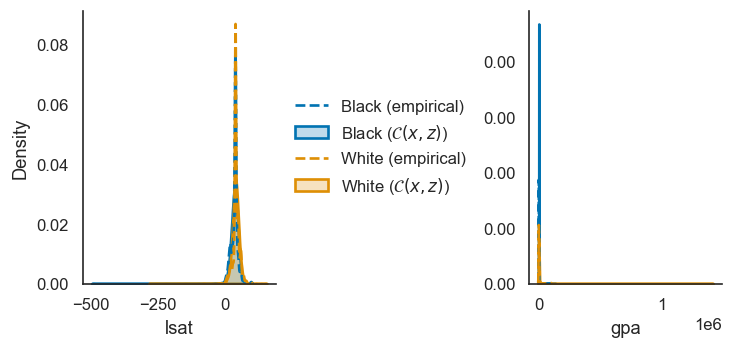

In [51]:
fig_marg = plot_conditional_marginals(
    X_va, Z_va, Wc_va, wc_names,
    sample_fn=sample_w_given_xz,
    scaler=scaler, K=50,
)

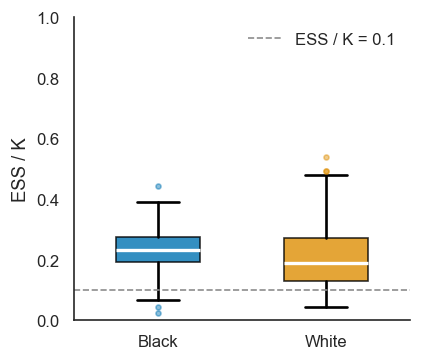

In [35]:
fig_ess = plot_ess_by_group(
    X_va,
    Z_va,
    sample_fn=sample_w_given_xz,
    log_prob_fn=log_prob_w_given_xz,
    K=50)

Interpretation of ratio:

- ESS/$K$ = 1.0 → all $K$ samples have equal weight, perfect coverage
- ESS/$K$ = 0.1 → only ~10% of samples are doing meaningful work, the rest have negligible weight
- ESS/$K$ < 0.1 → the NIE estimate is unreliable

This is showing that the ESS estimate is more reliable for the Black population, since the variance is tighter and clearing the 0.1 threshold
by a larger margin. However, this also means that the NIE can be more biased for the Black population. High ESS + large NIE → the flow is confidently estimating that a substantial portion of the bar passage gap is mediated through LSAT/GPA. The estimate is precise, and it's precisely capturing a disadvantage.

In [36]:
# ── 7b. Verify IS weight structure ───────────────────────────────────────────
# For NDE/NIE we need log P(w | x', z) vs log P(w | x, z).
# Here we just verify the log_prob_w_given_xz API works correctly.

if dim_wc > 0:
    N_is   = 50
    K_is   = 200

    # Sample w^(k) ~ P(W | x, z)
    x0 = X_va[:N_is]
    z0 = Z_va[:N_is]
    samples = sample_w_given_xz(x0, z0, K=K_is)

    # Simulate counterfactual sensitive attribute x'
    # (flip binary sensitive attribute for demonstration)
    x1 = 1.0 - x0  # (N_is, dim_x)
    x1_rep = x1.repeat_interleave(K_is, dim=0)
    z_rep  = samples["z_rep"]

    log_p_x1 = log_prob_w_given_xz(samples["w_disc"], samples["w_cont"], x1_rep, z_rep)
    log_p_x0 = samples["log_prob"]

    # IS weights r~_k = p(w|x',z) / p(w|x,z)
    log_r     = log_p_x1 - log_p_x0
    print(f"log IS weight stats  mean={log_r.mean():.3f}  std={log_r.std():.3f}  "
          f"min={log_r.min():.3f}  max={log_r.max():.3f}")

log IS weight stats  mean=-2.432  std=11.853  min=-310.525  max=6.745


## 8. Save Models

In [56]:
SAVE_DIR = f"outputs/flows/{DATASET_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    "g_phi_state":   g_phi.state_dict(),
    "f_theta_state": f_theta.state_dict(),
    "g_phi_cfg": dict(dim_x=dim_x, dim_z=dim_z, vocab=vocab),
    "f_theta_cfg": dict(dim_wc=dim_wc, dim_x=dim_x, dim_z=dim_z, vocab=vocab),
    "scaler":        scaler,
    "sfm_cfg":       cfg,
    "best_val_nll":  best_val,
    "best_epoch":    best_state["epoch"],
}, f"{SAVE_DIR}/flow_models.pt")

print(f"Models saved to {SAVE_DIR}/flow_models.pt")

Models saved to outputs/flows/adult/flow_models.pt


## 9. Load Models (for downstream steps)

Use this cell in the NDE/NIE and recourse notebooks to reload the trained flow.

In [25]:
def load_flow_models(checkpoint_path: str, device=DEVICE):
    """
    Reload trained g_phi and f_theta from a checkpoint.
    Returns (g_phi, f_theta, scaler, sfm_cfg).
    """
    ckpt     = torch.load(checkpoint_path, map_location=device, weights_only=False)
    g_cfg    = ckpt["g_phi_cfg"]
    f_cfg    = ckpt["f_theta_cfg"]

    g_phi_   = DiscreteMediator(**g_cfg).to(device)
    f_theta_ = ContinuousMediatorFlow(**f_cfg).to(device)

    g_phi_.load_state_dict(ckpt["g_phi_state"])
    f_theta_.load_state_dict(ckpt["f_theta_state"])

    g_phi_.eval(); f_theta_.eval()
    return g_phi_, f_theta_, ckpt["scaler"], ckpt["sfm_cfg"]

In [ ]:
# load teh law school flow models
g_phi, f_theta, scaler, sfm_cfg = load_flow_models("outputs/flows/law_school/flow_models.pt")

In [38]:
import pickle

os.makedirs("outputs/data", exist_ok=True)

torch.save({
    # Tensors
    "X_tr": X_tr, "Z_tr": Z_tr, "Wd_tr": Wd_tr, "Wc_tr": Wc_tr, "Y_tr": Y_tr,
    "X_va": X_va, "Z_va": Z_va, "Wd_va": Wd_va, "Wc_va": Wc_va, "Y_va": Y_va,
    # Metadata
    "scaler": scaler,
    "vocab":  vocab,
    "cfg":    cfg,
    "dim_x":  dim_x,
    "dim_z":  dim_z,
    "dim_wc": dim_wc,
    "dim_wd": dim_wd,
    "feat_names": feat_names if "feat_names" in dir() else None,
}, "outputs/data/bar_tensors.pt")

print("Saved tensors to outputs/data/bar_tensors.pt")

Saved tensors to outputs/data/bar_tensors.pt
